In [1]:
# IMPORTS
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly._subplots import make_subplots
import us

In [2]:
# LOAD PREPARED DATASET
df = pd.read_csv('prepared_congress_trading_dataset.csv')
print(df.head())

   Unnamed: 0 Ticker      Traded Transaction       Trade_Size_USD  \
0           0    NGL  2024-03-11        Sale    $15,001 - $50,000   
1           1    FCX  2024-02-29        Sale     $1,001 - $15,000   
2           2      V  2024-02-29    Purchase     $1,001 - $15,000   
3           3   AAPL  2024-02-29    Purchase            $1-$1,000   
4           4   MSFT  2024-02-29        Sale  $100,001 - $250,000   

               Name       Filed Party District Chamber       State  
0     Mark Dr Green  2024-03-13     R     TN07   House   Tennessee  
1   Josh Gottheimer  2024-03-07     D     NJ05   House  New Jersey  
2     Pete Sessions  2024-03-07     R     TX17   House       Texas  
3     Pete Sessions  2024-02-29     R     TX17   House       Texas  
4  Suzan K. Delbene  2024-03-08     D     WA01   House  Washington  


In [ ]:
# TRADING PER STATE

# Create Dataframe where each record 
df_state_party = df[['State', 'Party']].value_counts().reset_index(name="count")

us_state_abbr = {state.name: state.abbr for state in us.states.STATES}
rows = []
for state in us_state_abbr.keys():
    d_series = df_state_party[(df_state_party['State'] == state) & (df_state_party['Party'] == 'D')]
    d_count = d_series['count'].iloc[0] if not d_series.empty else 0
    i_series = df_state_party[(df_state_party['State'] == state) & (df_state_party['Party'] == 'I')]
    i_count = i_series['count'].iloc[0] if not i_series.empty else 0
    r_series = df_state_party[(df_state_party['State'] == state) & (df_state_party['Party'] == 'R')]
    r_count = r_series['count'].iloc[0] if not r_series.empty else 0
    # Add to data
    state_counts = [state, us.states.lookup(state).abbr, d_count, i_count, r_count]    
    rows.append(state_counts)
states_by_party = pd.DataFrame(rows, columns=['State Name', 'State', 'D', 'I', 'R'])

d_freq = px.choropleth(states_by_party[['State', 'D']], locations="State", locationmode="USA-states", color="D", color_continuous_scale='blues', scope="usa")
d_freq.update_layout(
    title="Frequency of Congressional Trades by Democrats per State",
    geo_scope="usa"
)

i_freq = px.choropleth(states_by_party[['State', 'I']], locations="State", locationmode="USA-states", color="I", color_continuous_scale='ylorbr', scope="usa")
i_freq.update_layout(
    title="Frequency of Congressional Trades by Independents per State",
    geo_scope="usa"
)

r_freq = px.choropleth(states_by_party[['State', 'R']], locations="State", locationmode="USA-states", color="R", color_continuous_scale='reds', scope="usa")
r_freq.update_layout(
    title="Frequency of Congressional Trades by Republicans per State",
    geo_scope="usa"
)

d_freq.show()
i_freq.show()
r_freq.show()


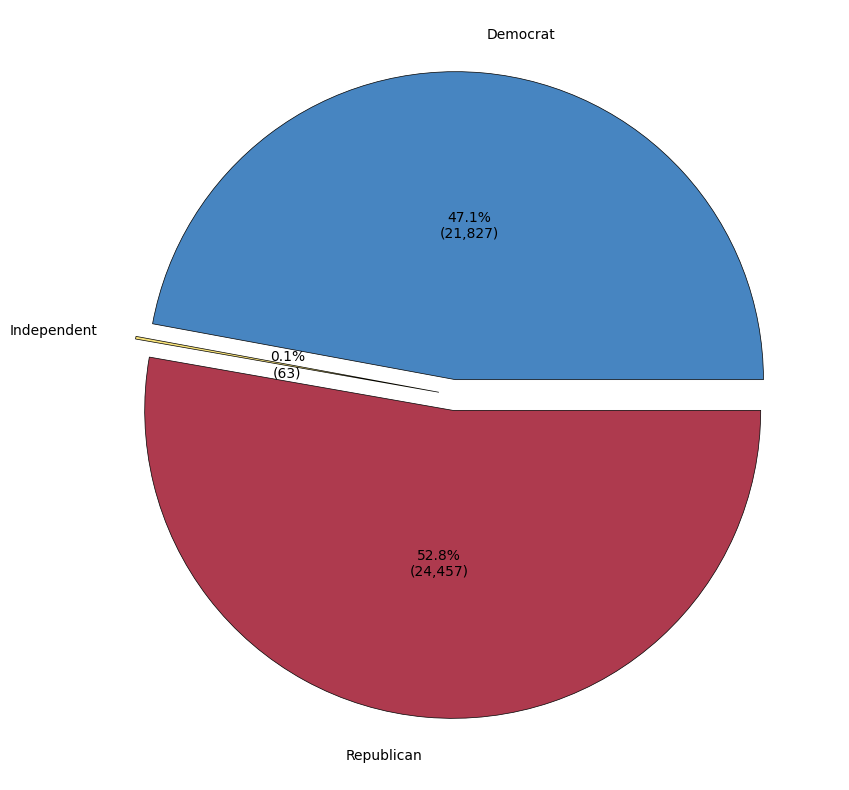

In [88]:
# showcasing possible class imbalance
def inner_label(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%\n({:,})".format(pct, absolute)

counts_df_party = df.groupby("Party").size().reset_index(name="count")
counts_df_party
plt.figure(figsize=(10, 8))
plt.pie(
    x=counts_df_party["count"], 
    autopct=lambda pct: inner_label(pct, counts_df_party["count"]),
    explode=(0.05, 0.05, 0.05),
    labels=['Democrat', 'Independent', 'Republican'],
    colors=['#4785c1', '#f7e278', '#ae3a4e'],
    pctdistance=.5, labeldistance=1.125,
    wedgeprops={"edgecolor":"k",'linewidth': 0.5, 'linestyle': 'solid', 'antialiased': True})
# # plt.xlabel("Party")
# # plt.ylabel("Count")
# plt.title("Trading Done By Each Party")
plt.tight_layout()
plt.show()

In [6]:
def midpoint(range_str):
    clean = range_str.replace("$", "").replace(",", "")
    
    # Split on dash
    low, high = clean.split("-")
    
    # Convert to integers
    low = int(low.strip())
    high = int(high.strip())
    
    # Midpoint
    return (low + high) / 2


df["Midpoint Trade Size"] = df["Trade_Size_USD"].apply(midpoint)

In [7]:
state_sums = df.groupby("State")["Midpoint Trade Size"].sum().reset_index()

In [8]:
state_sums

,State,Midpoint Trade Size
0,AK,1798559.0
1,AL,33487173.0
2,AR,39084531.0
3,AZ,3251194.0
4,CA,174795819.5
5,CO,13098128.0
6,CT,1481573.5
7,DE,6785875.5
8,FL,61018944.5
9,GA,179707971.0


In [9]:
px.choropleth(state_sums,locations="State",locationmode="USA-states",color="Midpoint Trade Size",color_continuous_scale="Greens",scope="usa").show()

In [10]:
# Convert dates to datetime
df['Traded'] = pd.to_datetime(df['Traded'])
df['Filed'] = pd.to_datetime(df['Filed'])

# Days between trade and filing
df['Days_To_File'] = (df['Filed'] - df['Traded']).dt.days

# Month (1-12)
df['Month'] = df['Traded'].dt.month

# Year
df['Year'] = df['Traded'].dt.year


<Figure size 800x600 with 0 Axes>

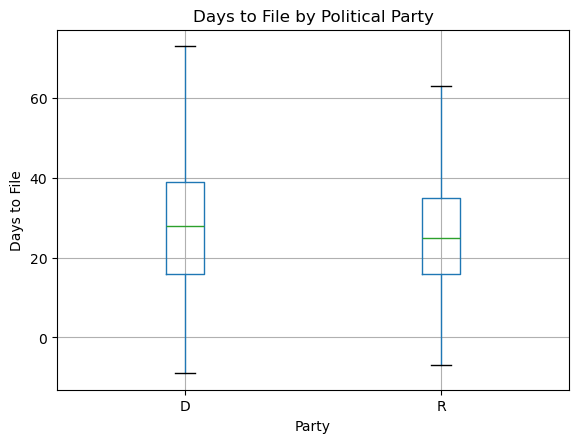

In [16]:
df = df[df["Party"].isin(["R", "D"])]

plt.figure(figsize=(8,6))
df.boxplot(column="Days_To_File", by="Party",showfliers=False)
plt.title("Days to File by Political Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Days to File")
plt.show()

In [15]:
from scipy.stats import ttest_ind


d_values = df[df_filtered["Party"] == "D"]["Days_To_File"]
r_values = df[df_filtered["Party"] == "R"]["Days_To_File"]

t_stat, p_value = ttest_ind(d_values, r_values, equal_var=False)  # Welch's t-test

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 13.328597704265864
p-value: 1.9224264852381368e-40


In [19]:
count_table = df.pivot_table(
    index="Month",
    columns="Party",
    aggfunc="size",
    fill_value=0
)

# Convert to column-wise percentages
pct_column = count_table.apply(lambda col: col / col.sum(), axis=0)

print(pct_column)

Party         D         R
Month                    
1      0.097306  0.113996
2      0.095794  0.097927
3      0.110271  0.110807
4      0.088006  0.079691
5      0.079164  0.079977
6      0.088693  0.065993
7      0.093641  0.064767
8      0.067161  0.066484
9      0.074537  0.079691
10     0.067345  0.071513
11     0.072751  0.065952
12     0.065329  0.103202


In [21]:
df.head

<bound method NDFrame.head of        Unnamed: 0 Ticker     Traded Transaction       Trade_Size_USD  \
0               0    NGL 2024-03-11        Sale    $15,001 - $50,000   
1               1    FCX 2024-02-29        Sale     $1,001 - $15,000   
2               2      V 2024-02-29    Purchase     $1,001 - $15,000   
3               3   AAPL 2024-02-29    Purchase            $1-$1,000   
4               4   MSFT 2024-02-29        Sale  $100,001 - $250,000   
...           ...    ...        ...         ...                  ...   
46344       46462    CAT 2012-07-26    Purchase     $1,001 - $15,000   
46345       46463     PG 2012-07-24        Sale     $1,001 - $15,000   
46346       46464    KSU 2012-06-06    Purchase     $1,001 - $15,000   
46347       46465   EP$C 2012-03-20        Sale     $1,001 - $15,000   
46348       46466   EP$C 2012-02-27        Sale     $1,001 - $15,000   

                        Name      Filed Party District Chamber State  \
0              Mark Dr Green 2024

In [24]:
count_table = df.pivot_table(
    index="Trade_Size_USD",
    columns="Party",
    aggfunc="size",
    fill_value=0
)

# Convert to column-wise percentages
pct_column = count_table.apply(lambda col: col / col.sum(), axis=0)

print(pct_column)

Party                             D         R
Trade_Size_USD                               
$1,000,001 - $5,000,000    0.003619  0.000981
$1,001 - $15,000           0.803876  0.674408
$1-$1,000                  0.018737  0.001799
$100,001 - $250,000        0.014706  0.046122
$15,001 - $50,000          0.120121  0.203704
$25,000,001 - $50,000,000  0.000046  0.000082
$250,001 - $500,000        0.005772  0.010058
$5,000,001 - $25,000,000   0.000641  0.000204
$50,001 - $100,000         0.028266  0.059329
$500,001 - $1,000,000      0.004215  0.003312


In [27]:
df1 = df[df["Name"].isin(['Mark Dr Green'])]
df1 = df[df["Ticker"].isin(['NGL'])]
df1

,Unnamed: 0,Ticker,Traded,Transaction,Trade_Size_USD,Name,Filed,Party,District,Chamber,State,Midpoint Trade Size,Days_To_File,Month,Year
0,0,NGL,2024-03-11,Sale,"$15,001 - $50,000",Mark Dr Green,2024-03-13,R,TN07,House,TN,32500.5,2,3,2024
17,17,NGL,2024-02-26,Sale,"$50,001 - $100,000",Mark Dr Green,2024-02-29,R,TN07,House,TN,75000.5,3,2,2024
114,116,NGL,2024-01-29,Sale,"$100,001 - $250,000",Mark Dr Green,2024-02-01,R,TN07,House,TN,175000.5,3,1,2024
363,368,NGL,2024-01-11,Sale,"$100,001 - $250,000",Mark Dr Green,2024-01-17,R,TN07,House,TN,175000.5,6,1,2024
1902,1916,NGL,2023-08-04,Purchase,"$250,001 - $500,000",Mark Dr Green,2023-08-08,R,TN07,House,TN,375000.5,4,8,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43830,43939,NGL,2014-07-28,Sale,"$100,001 - $250,000",Mr. Bill Flores,2014-08-12,R,TX17,House,TX,175000.5,15,7,2014
44041,44150,NGL,2014-06-23,Purchase,"$15,001 - $50,000",Mr. Bill Flores,2014-07-10,R,TX17,House,TX,32500.5,17,6,2014
44093,44202,NGL,2014-06-18,Purchase,"$50,001 - $100,000",Mr. Bill Flores,2014-07-10,R,TX17,House,TX,75000.5,22,6,2014
46213,46330,NGL,2013-12-19,Sale,"$250,001 - $500,000",Mr. Bill Flores,2014-01-07,R,TX17,House,TX,375000.5,19,12,2013
